In [18]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers, models, optimizers, losses, metrics
import matplotlib.pyplot as plt
from PIL import Image
import time
import wandb

In [19]:
IMAGE_SIZE = 128
CHANNELS = 3

BATCH_SIZE = 64
Z_DIM = 100
EPOCHS_FULL_TRAIN = 200   

LEARNING_RATE_G = 0.0002  
LEARNING_RATE_D = 0.0002  
ADAM_BETA_1 = 0.5
ADAM_BETA_2 = 0.999

D_LR_DECAY_FACTOR = 0.95  
D_LR_DECAY_EVERY = 5       
D_LR_MIN = 0.00005        

NOISE_PARAM = 0.05

DATA_ROOT = "fish-dataset"
OUT_DIR = "outputs_keras"
CKPT_DIR = "checkpoints_keras"

# #early stopping
# PATIENCE = 10
# MIN_DELTA = 0.01

USE_WANDB = True
WANDB_PROJECT = "fish-dcgan"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

In [21]:
def make_dataset(num_images=None):
    ds = keras.utils.image_dataset_from_directory(
        DATA_ROOT,
        label_mode=None,
        image_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=42,
    )
    
    #normalize to [-1, 1]
    norm = layers.Rescaling(scale=1.0 / 127.5, offset=-1.0)
    ds = ds.map(lambda x: norm(tf.cast(x, tf.float32)), num_parallel_calls=tf.data.AUTOTUNE)
    
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_full = make_dataset()

Found 3983 files.


In [22]:
NGF = 64

def build_generator(z_dim=Z_DIM, ngf=NGF):
    inp = layers.Input(shape=(z_dim,))
    x = layers.Reshape((1, 1, z_dim))(inp)

    x = layers.Conv2DTranspose(ngf * 8, 4, strides=1, padding="valid", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(ngf * 4, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(ngf * 2, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(ngf, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(ngf // 2, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    out = layers.Conv2DTranspose(
        CHANNELS, 4, strides=2, padding="same", use_bias=False, activation="tanh"
    )(x)

    return models.Model(inp, out, name="generator")

In [23]:
NDF = 64

def build_discriminator(img_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS), ndf=NDF):
    inp = layers.Input(shape=img_shape)

    x = layers.Conv2D(ndf, 4, strides=2, padding="same", use_bias=False)(inp)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(ndf * 2, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(ndf * 4, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(ndf * 8, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(ndf * 8, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(1, 4, strides=1, padding="valid", use_bias=False)(x)
    out = layers.Flatten()(x)

    return models.Model(inp, out, name="discriminator")

In [24]:
class DCGAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim, noise_param=0.05):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.noise_param = noise_param
        self.loss_fn = losses.BinaryCrossentropy(from_logits=True)
        
        self.current_d_lr = LEARNING_RATE_D

    def compile(self, d_optimizer, g_optimizer):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.d_loss_metric = metrics.Mean(name="d_loss")
        self.g_loss_metric = metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        if isinstance(real_images, tuple):
            real_images = real_images[0]

        batch_size = tf.shape(real_images)[0]
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            generated_images = self.generator(random_latent_vectors, training=True)

            real_predictions = self.discriminator(real_images, training=True)
            fake_predictions = self.discriminator(generated_images, training=True)

            real_labels = tf.ones_like(real_predictions)
            fake_labels = tf.zeros_like(fake_predictions)

            real_noisy_labels = real_labels - self.noise_param * tf.random.uniform(
                tf.shape(real_predictions), 0.0, 1.0
            )
            fake_noisy_labels = fake_labels + self.noise_param * tf.random.uniform(
                tf.shape(fake_predictions), 0.0, 1.0
            )

            d_real_loss = self.loss_fn(real_noisy_labels, real_predictions)
            d_fake_loss = self.loss_fn(fake_noisy_labels, fake_predictions)
            d_loss = (d_real_loss + d_fake_loss) / 2.0

            g_loss = self.loss_fn(tf.ones_like(fake_predictions), fake_predictions)

        grad_d = disc_tape.gradient(d_loss, self.discriminator.trainable_variables)
        grad_g = gen_tape.gradient(g_loss, self.generator.trainable_variables)

        self.d_optimizer.apply_gradients(zip(grad_d, self.discriminator.trainable_variables))
        self.g_optimizer.apply_gradients(zip(grad_g, self.generator.trainable_variables))

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)

        return {m.name: m.result() for m in self.metrics}

In [25]:
#reduce discriminator learning rate so it doesn't get too strong
class DiscriminatorLRDecay(keras.callbacks.Callback):
    def __init__(self, decay_factor=0.95, decay_every=5, min_lr=0.00005):
        super().__init__()
        self.decay_factor = decay_factor
        self.decay_every = decay_every
        self.min_lr = min_lr
    
    def on_epoch_end(self, epoch, logs=None):

        if (epoch + 1) % self.decay_every == 0:
            old_lr = self.model.d_optimizer.learning_rate.numpy()
            new_lr = max(old_lr * self.decay_factor, self.min_lr)
            self.model.d_optimizer.learning_rate.assign(new_lr)
            self.model.current_d_lr = new_lr
            print(f"\ndiscriminator lr: {old_lr:.6f} → {new_lr:.6f}")


class WandbImageCallback(keras.callbacks.Callback):
    
    def __init__(self, latent_dim, num_samples=16):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_samples = num_samples
        self.fixed_latent = tf.random.normal(shape=(num_samples, latent_dim))
    
    def denorm_to_01(self, x):
        return (x + 1.0) / 2.0
    
    def on_epoch_end(self, epoch, logs=None):
        fake = self.model.generator(self.fixed_latent, training=False)
        fake_01 = tf.clip_by_value(self.denorm_to_01(fake), 0.0, 1.0)
        
        fig, axes = plt.subplots(4, 4, figsize=(8, 8))
        for i, ax in enumerate(axes.flat):
            ax.imshow(fake_01[i].numpy())
            ax.axis("off")
        plt.suptitle(f"Epoch {epoch + 1}")
        plt.tight_layout()
        
        if USE_WANDB:
            wandb.log({"samples": wandb.Image(fig)}, step=epoch)
        
        plt.close(fig)


# class EarlyStoppingCallback(keras.callbacks.Callback):
    
#     def __init__(self, patience=10, min_delta=0.01):
#         super().__init__()
#         self.patience = patience
#         self.min_delta = min_delta
#         self.best_loss = float('inf')
#         self.wait = 0
    
#     def on_epoch_end(self, epoch, logs=None):
#         current_loss = logs.get('g_loss')
#         if current_loss is None:
#             return
        
#         if current_loss < self.best_loss - self.min_delta:
#             self.best_loss = current_loss
#             self.wait = 0
#             self.model.generator.save_weights(os.path.join(CKPT_DIR, "g_best.weights.h5"))
#             self.model.discriminator.save_weights(os.path.join(CKPT_DIR, "d_best.weights.h5"))
#         else:
#             self.wait += 1
#             if self.wait >= self.patience:
#                 self.model.stop_training = True
#                 print(f"\nearly stopping at epoch {epoch + 1}. Best G loss: {self.best_loss:.4f}")

In [ ]:
def interpolate_latent(z1, z2, num_steps=10):
    z1 = np.array(z1).flatten()
    z2 = np.array(z2).flatten()
    
    alphas = np.linspace(0, 1, num_steps)
    interpolated = []
    
    for alpha in alphas:
        z = z1 * (1 - alpha) + z2 * alpha
        interpolated.append(z)
    
    return np.array(interpolated)  
 
 
def create_interpolation_grid(generator, z_dim, num_pairs=4, steps_per_pair=10):
    fig, axes = plt.subplots(num_pairs, steps_per_pair, figsize=(15, 6))
    
    for row in range(num_pairs):
        z1 = tf.random.normal(shape=(z_dim,))  # Shape: (z_dim,)
        z2 = tf.random.normal(shape=(z_dim,))  # Shape: (z_dim,)
        
        # Interpolate
        z_interp = interpolate_latent(z1, z2, steps_per_pair)  # Shape: (steps, z_dim)
        
        # Generate images
        images = generator(z_interp, training=False)
        images_01 = tf.clip_by_value((images + 1.0) / 2.0, 0.0, 1.0)
        
        # Plot
        for col in range(steps_per_pair):
            axes[row, col].imshow(images_01[col].numpy())
            axes[row, col].axis('off')
    
    plt.suptitle('Latent Space Interpolation')
    plt.tight_layout()
    return fig
 
 
def create_interpolation_gif(generator, z_dim, filename='interpolation.gif', num_frames=60):
    """Create GIF animating interpolation"""
    # Sample two random latent vectors
    z1 = tf.random.normal(shape=(z_dim,))  # Shape: (z_dim,)
    z2 = tf.random.normal(shape=(z_dim,))  # Shape: (z_dim,)
    
    # Interpolate
    z_interp = interpolate_latent(z1, z2, num_frames)  # Shape: (num_frames, z_dim)
    
    # Generate images
    images = generator(z_interp, training=False)
    images_01 = tf.clip_by_value((images + 1.0) / 2.0, 0.0, 1.0)
    
    # Convert to PIL images
    pil_images = []
    for i in range(num_frames):
        img_array = (images_01[i].numpy() * 255).astype(np.uint8)
        pil_images.append(Image.fromarray(img_array))
    
    # Save as GIF
    pil_images[0].save(
        filename,
        save_all=True,
        append_images=pil_images[1:],
        duration=50,  # ms per frame
        loop=0
    )
    print(f"Saved interpolation GIF to {filename}")
 
 

In [27]:
def train_dcgan(dataset, epochs, lr_g, lr_d, noise_param, use_wandb=True, run_name=None):
    # Initialize W&B
    if use_wandb:
        wandb.init(
            project=WANDB_PROJECT,
            name=run_name,
            config={
                "batch_size": BATCH_SIZE,
                "z_dim": Z_DIM,
                "lr_g": lr_g,
                "lr_d": lr_d,
                "noise_param": noise_param,
                "epochs": epochs,
                "d_lr_decay_factor": D_LR_DECAY_FACTOR,
                "d_lr_decay_every": D_LR_DECAY_EVERY,
            }
        )
    
    gen = build_generator(z_dim=Z_DIM)
    disc = build_discriminator()
    
    dcgan = DCGAN(discriminator=disc, generator=gen, latent_dim=Z_DIM, noise_param=noise_param)
    
    dcgan.compile(
        d_optimizer=optimizers.Adam(learning_rate=lr_d, beta_1=ADAM_BETA_1, beta_2=ADAM_BETA_2),
        g_optimizer=optimizers.Adam(learning_rate=lr_g, beta_1=ADAM_BETA_1, beta_2=ADAM_BETA_2),
    )
    
    callbacks = [
        DiscriminatorLRDecay(
            decay_factor=D_LR_DECAY_FACTOR,
            decay_every=D_LR_DECAY_EVERY,
            min_lr=D_LR_MIN
        )
#         EarlyStoppingCallback(patience=PATIENCE, min_delta=MIN_DELTA)
    ]
    
    if use_wandb:
        callbacks.append(WandbImageCallback(latent_dim=Z_DIM))
        callbacks.append(keras.callbacks.LambdaCallback(
            on_epoch_end=lambda epoch, logs: wandb.log({
                "d_loss": logs['d_loss'],
                "g_loss": logs['g_loss'],
                "d_lr": dcgan.current_d_lr,
                "epoch": epoch
            })
        ))
    
    start_time = time.time()
    history = dcgan.fit(dataset, epochs=epochs, callbacks=callbacks)
    train_time = time.time() - start_time
    
    best_g_loss = min(history.history['g_loss'])
    
    if use_wandb:
        wandb.log({"train_time_seconds": train_time, "best_g_loss": best_g_loss})
        wandb.finish()
    
    return dcgan, history, best_g_loss, train_time

In [28]:
BEST_LR_G = 0.0002
BEST_LR_D = 0.0002
# BEST_NOISE = 0.1

In [29]:
dcgan_final, history_final, _, _ = train_dcgan(
    dataset=train_ds_full,
    epochs=EPOCHS_FULL_TRAIN,
    lr_g=BEST_LR_G,
    lr_d=BEST_LR_D,
    noise_param=NOISE_PARAM,
    use_wandb=USE_WANDB,
    run_name="final_full_training"
)

dcgan_final.generator.save_weights(os.path.join(CKPT_DIR, "g_final.weights.h5"))
dcgan_final.discriminator.save_weights(os.path.join(CKPT_DIR, "d_final.weights.h5"))

Epoch 1/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - d_loss: 0.5270 - g_loss: 13.3938
Epoch 2/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - d_loss: 0.2549 - g_loss: 8.0689
Epoch 3/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - d_loss: 0.1891 - g_loss: 4.3687
Epoch 4/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - d_loss: 0.1674 - g_loss: 3.9502
Epoch 5/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - d_loss: 0.2993 - g_loss: 4.6320
discriminator lr: 0.000200 → 0.000190
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - d_loss: 0.2278 - g_loss: 3.9784
Epoch 6/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - d_loss: 0.2785 - g_loss: 3.2005
Epoch 7/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - d_loss: 0.3066 - g_loss: 2.9276
Epoch 8/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - d_loss: 0.2966 - g_loss: 2.5710
Epoch 9/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - d_loss: 0.2560 - g_loss: 3.3746
Epoch 10/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - d_loss: 0.3043 - g_loss: 3.2295
discriminator lr: 0.000190 → 0

Epoch 56/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - d_loss: 0.2251 - g_loss: 3.1884
Epoch 57/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - d_loss: 0.2067 - g_loss: 3.1261
Epoch 58/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - d_loss: 0.2131 - g_loss: 3.3527
Epoch 59/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - d_loss: 0.2133 - g_loss: 3.3253
Epoch 60/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - d_loss: 0.2538 - g_loss: 3.5757
discriminator lr: 0.000114 → 0.000108
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - d_loss: 0.2302 - g_loss: 3.3041
Epoch 61/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - d_loss: 0.1864 - g_loss: 3.0482
Epoch 62/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - d_loss: 0.2024 - g_loss: 3.4271
Epoch 63/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - d_loss: 0.1831 - g_loss: 3.3391
Epoch 64/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - d_loss: 0.1967 - g_loss: 3.1985
Epoch 65/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - d_loss: 0.1963 - g_loss: 3.3327
discriminator lr: 0.00

Epoch 111/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - d_loss: 0.1719 - g_loss: 3.6307
Epoch 112/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - d_loss: 0.1616 - g_loss: 3.5476
Epoch 113/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - d_loss: 0.1677 - g_loss: 3.6053
Epoch 114/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - d_loss: 0.1807 - g_loss: 3.9665
Epoch 115/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - d_loss: 0.1843 - g_loss: 4.0320
discriminator lr: 0.000065 → 0.000061
63/63 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - d_loss: 0.1706 - g_loss: 3.7730
Epoch 116/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - d_loss: 0.1598 - g_loss: 3.3532
Epoch 117/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - d_loss: 0.1688 - g_loss: 3.6164
Epoch 118/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - d_loss: 0.1858 - g_loss: 3.9702
Epoch 119/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - d_loss: 0.1591 - g_loss: 3.3920
Epoch 120/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - d_loss: 0.1945 - g_loss: 4.4340
discriminato

Epoch 166/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - d_loss: 0.2068 - g_loss: 4.1152
Epoch 167/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - d_loss: 0.1507 - g_loss: 3.4133
Epoch 168/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - d_loss: 0.2173 - g_loss: 4.1750
Epoch 169/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - d_loss: 0.1613 - g_loss: 3.3454
Epoch 170/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - d_loss: 0.2227 - g_loss: 4.5638
discriminator lr: 0.000050 → 0.000050
63/63 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - d_loss: 0.1744 - g_loss: 3.7589
Epoch 171/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - d_loss: 0.1630 - g_loss: 3.4665
Epoch 172/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - d_loss: 0.1613 - g_loss: 3.3358
Epoch 173/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - d_loss: 0.1654 - g_loss: 3.8007
Epoch 174/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - d_loss: 0.1651 - g_loss: 3.4982
Epoch 175/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - d_loss: 0.3136 - g_loss: 4.7311
discriminato

best_g_loss,▁
d_loss,▅▆▄██▆▅▅▅▇▃▂▃▃▂▂▂▁▂▂▂▂▂▂▂▂▁▂▁▂▂▂▂▁▄▂▁▂▁▁
d_lr,████▇▇▆▆▆▅▅▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇███
g_loss,▁▄▂▂▂▂▂▁▂▂▂▃▃▄▄▄▆▅▅▄▆▄█▅▇▅▅▆▄▅▄▅▅▅▄▇▆▄▆▅
train_time_seconds,▁
best_g_loss,2.53825
d_loss,0.1659
d_lr,5e-05
epoch,199
g_loss,3.53063


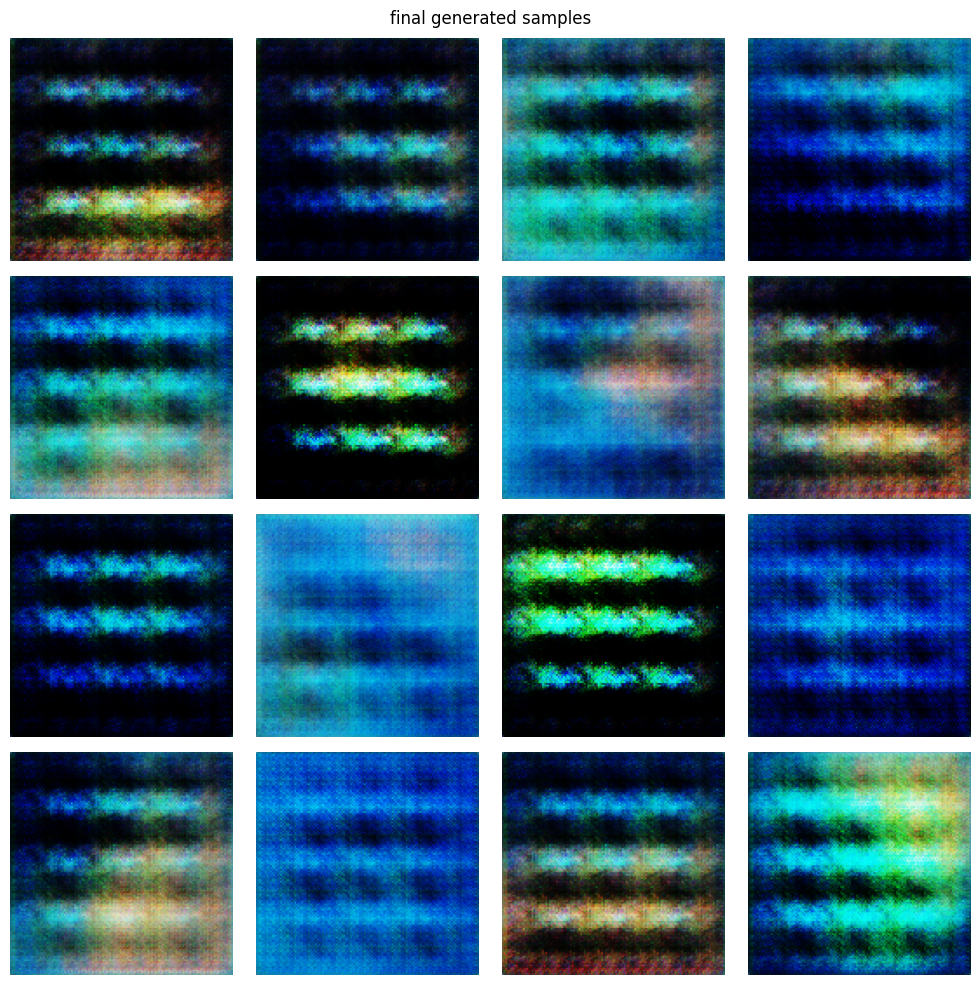

In [32]:
generator = build_generator()
generator.load_weights(os.path.join(CKPT_DIR, "g_best.weights.h5"))

def denorm_to_01(x):
    return (x + 1.0) / 2.0

n_show = 16
z_sample = tf.random.normal(shape=(n_show, Z_DIM))
fake = generator(z_sample, training=False)
fake_01 = tf.clip_by_value(denorm_to_01(fake), 0.0, 1.0)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(fake_01[i].numpy())
    ax.axis("off")
plt.suptitle("final generated samples")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "samples_grid.png"), dpi=150)
plt.show()

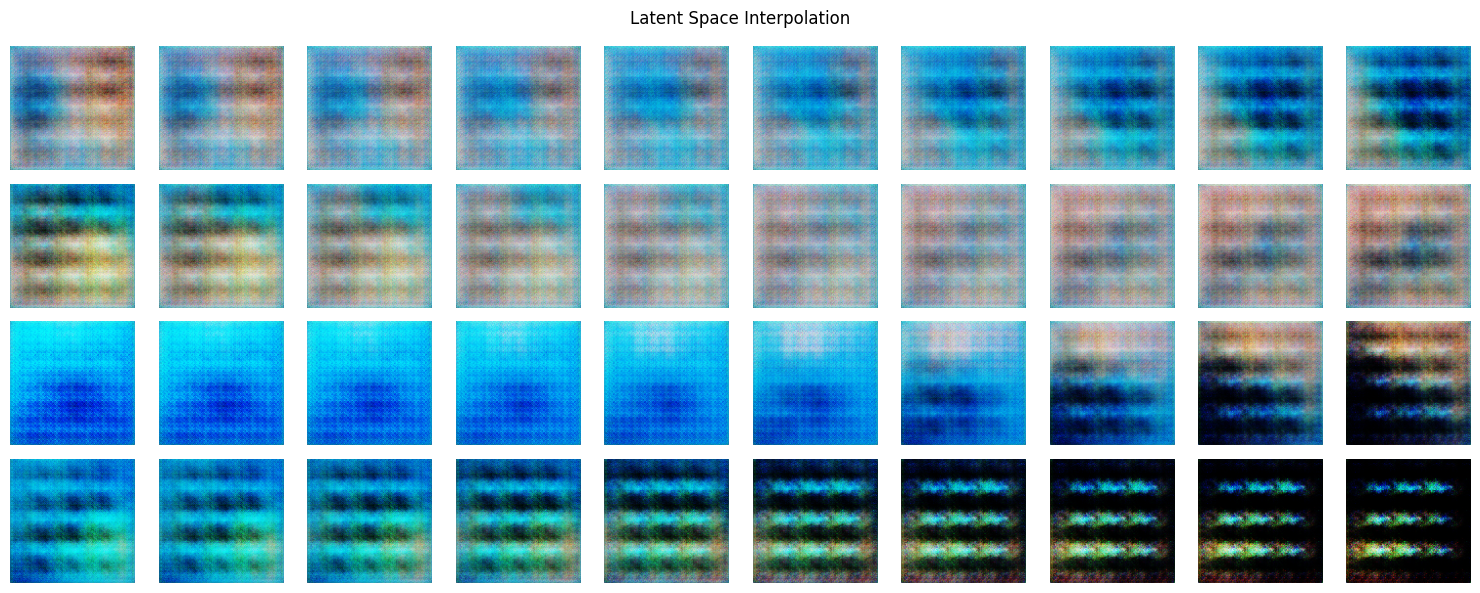

In [36]:
fig = create_interpolation_grid(generator, Z_DIM, num_pairs=4, steps_per_pair=10)
plt.savefig(os.path.join(OUT_DIR, "interpolation_grid.png"), dpi=150)
plt.show()

In [37]:
create_interpolation_gif(
    generator, 
    Z_DIM, 
    filename=os.path.join(OUT_DIR, "interpolation.gif"),
    num_frames=60
)

Saved interpolation GIF to outputs_keras/interpolation.gif


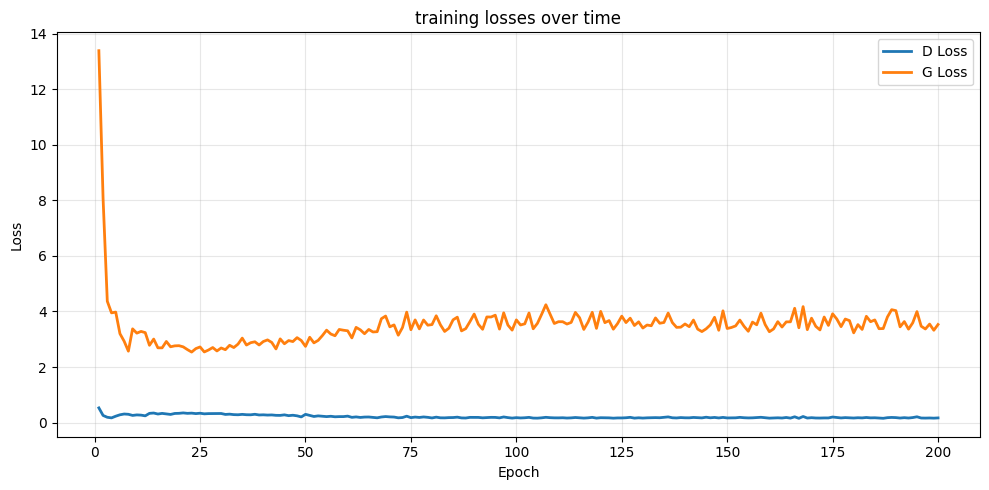

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

epochs_range = range(1, len(history_final.history['d_loss']) + 1)
ax.plot(epochs_range, history_final.history['d_loss'], label='D Loss', linewidth=2)
ax.plot(epochs_range, history_final.history['g_loss'], label='G Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('training losses over time')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "loss_curves.png"), dpi=150)
plt.show()